## Banknote authentication using classification algorithms

In this project we want to undestand how to recognize true banknotes from false one. This question is crucial in several businesses, such as banks and large corporations. The main goal here is to avoid financial losses.

To recognize the banknotes we use the **discrete wavelet transform (DWT)** which decomposes an image into wavelet coefficients representing information at different scales and positions.

A wavelet coefficient is calculated as

$$
W(j,k)=\sum_n x[n]\psi_{j,k}[n]
$$

where $x[n]$ is the signal and $\psi_{j,k}[n]$ is the wavelet function at a certain scale $j$ and position $k$.

The wavelet function changes its size and position to detect different image patterns. Small scales capture fine details, while larger scales capture broader structures.

From the transformed image, statistical features are then extracted.

Variance

$$
\sigma^2=\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2
$$

It measures how much the wavelet coefficients vary around their mean.

Skewness

$$
\frac{1}{N}\sum_{i=1}^{N}
\left(\frac{x_i-\mu}{\sigma}\right)^3
$$

It measures the asymmetry of the coefficient distribution.

Kurtosis
$$
\frac{1}{N}\sum_{i=1}^{N}
\left(\frac{x_i-\mu}{\sigma}\right)^4
$$

It describes the shape and tail concentration of the distribution.

Entropy

$$
H=-\sum_{i=1}^{m}p_i\log_2(p_i)
$$

Entropy measures the randomness or information contained in the transformed image.

Let us now start initializing the libraries pandas, matplotlib, seaborn and sklearn.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from metric_classification import evaluate_model


In [3]:
df=pd.read_csv("banknote.txt")
print(df.head())

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


## Data cleaning and visualization


In this section we check:

-) the number of missing values and duplicate rows

-) shape our dataframe

-) visualisation of the datas

In [4]:
df.isna().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

In [5]:
print("Number of duplicated rows:", df.duplicated().sum())
df=df.drop_duplicates()

Number of duplicated rows: 24


In [6]:
df.shape

(1348, 5)

In [7]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1348.000000,1348.000000,1348.000000,1348.000000,1348.000000
mean,0.445785,1.909039,1.413578,-1.168712,0.452522
std,2.862906,5.868600,4.328365,2.085877,0.497925
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.786650,-1.627000,-1.545600,-2.393100,0.000000
50%,0.518735,2.334150,0.605495,-0.578890,0.000000
75%,2.853250,6.796025,3.199800,0.403863,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


We checked that there are no missing values and we removed the duplicates. Now let us plot the histogram to visualize the distribution of the data, the number of positive and negative cases and, finally, compute the correlation matrix.

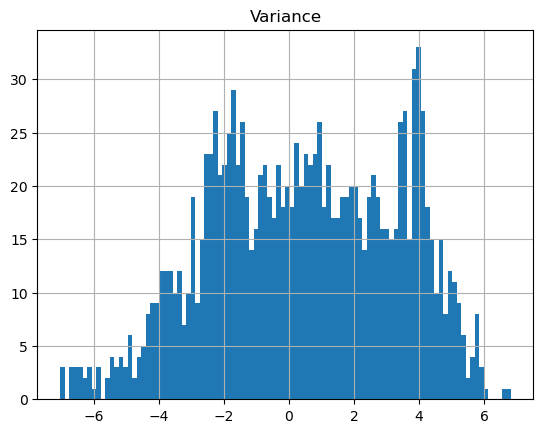

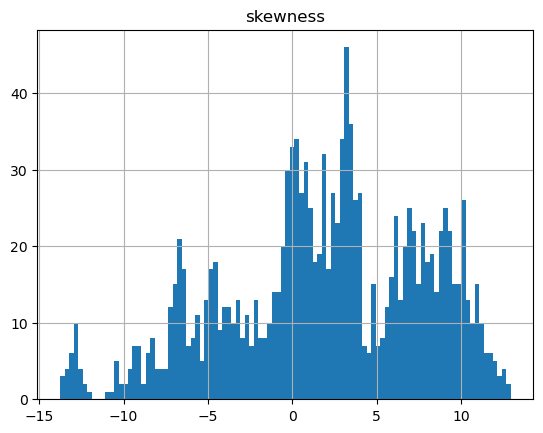

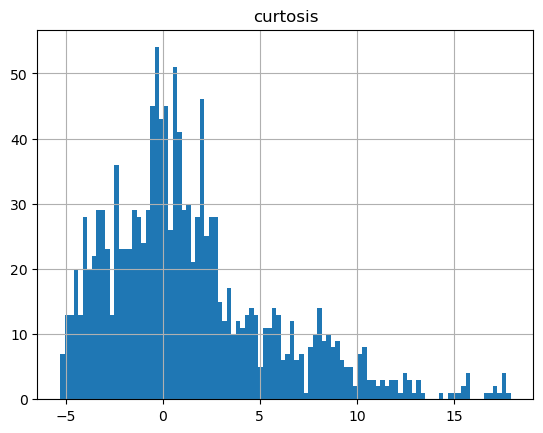

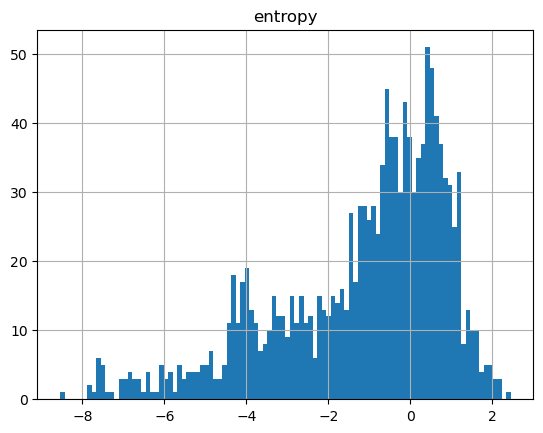

In [8]:
df["variance"].hist(bins=100)
plt.title("Variance")
plt.show()
df["skewness"].hist(bins=100)
plt.title("skewness")
plt.show()
df["curtosis"].hist(bins=100)
plt.title("curtosis")
plt.show()
df["entropy"].hist(bins=100)
plt.title("entropy")
plt.show()

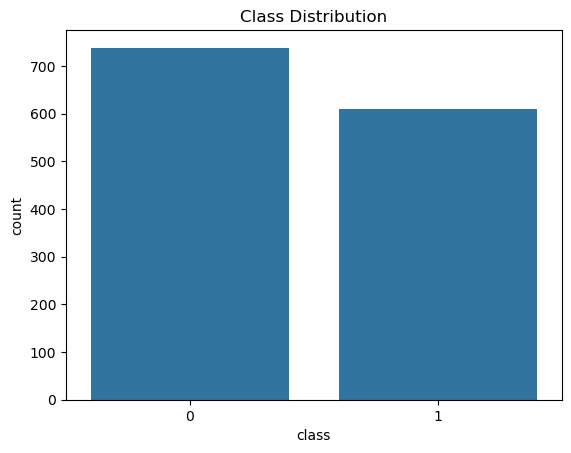

In [9]:
sns.countplot(x='class', data=df)
plt.title('Class Distribution')
plt.show()

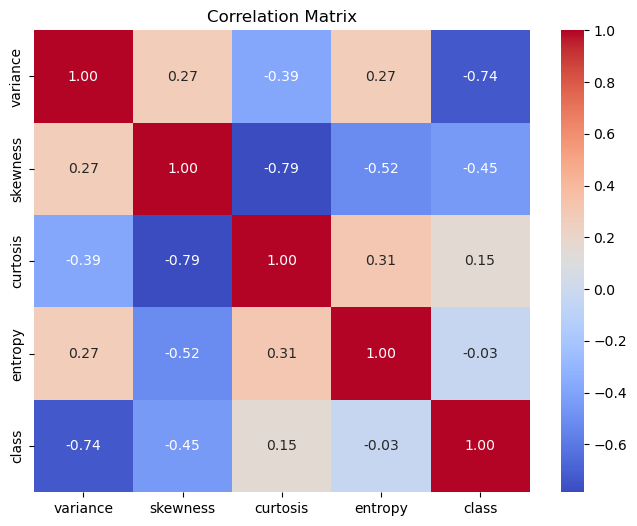

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Preprocessing and hyperparametrization of the models

Before start with the process of hyperparametrization (where we will use an heuristic grid approach since the dataframe is small) we rescale the data. Standardization rescales each feature so that it has a mean of approximately 0 and a standard deviation of 1, without changing the underlying shape of its distribution, i.e.

$$
X_{scaled} = \frac{X-\mu}{\sigma}
$$

where $\mu$ is the mean of the function $X$ and $\sigma$ its standard deviation.

In [11]:
scaler = StandardScaler()

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We start now with the hyperparametrization of the logistic regression, which is our baseline model.

First, it computes a linear regression of the input features:

$$
z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
$$

where in this case are the parameters in the database (4 parameters)

Then, the sigmoid function converts this value into a probability between 0 and 1:

$$
P(y=1)=\frac{1}{1+e^{-z}}
$$

A common decision rule is:

$$
P(y=1) \geq 0.5 \Rightarrow \text{class } 1
$$

$$
P(y=1) < 0.5 \Rightarrow \text{class } 0
$$

but this parameter may be changed. The parameter $C$ represents the penalization argument during the linear regression.

In [12]:

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid={"C": [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Best C:", grid.best_params_)
par_c=grid.best_params_

Best C: {'C': 10}


We apply now the hyperparametrization on the KNN algorithm, which is a supervised machine learning algorithm.

It finds the K closest data points to a new sample and the new sample is assigned to the class with the majority vote among its neighbors.

It is a pretty simple algorithm to be described and applied, unfortunately this may be exprensive computationally if the the number of neighbors evaluated is high.

In [13]:
params = {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}

grid = GridSearchCV( KNeighborsClassifier(), param_grid=params, cv=5, scoring="accuracy")

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)
KNN_best=grid.best_params_

{'n_neighbors': 3, 'weights': 'distance'}
0.9972222222222221


Now we compute the grid hyperparametrization on **support vector classifier**, which is a supervised machine learning algorithm used for classification.

The idea is that it finds the best decision boundary (hyperplane for "linear" or non linear curve for "rbf") that separates different classes.

It tries to maximize the margin, i.e., the distance between the boundary and the closest data points.

In [14]:
params = {"C": [0.1, 1, 10, 100], "kernel": ["linear", "rbf"], }

grid = GridSearchCV(SVC(), param_grid=params, cv=5, scoring="accuracy")

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
best_SVC = grid.best_params_

{'C': 10, 'kernel': 'rbf'}


We now use the **random forest classification** algorithm, which is a bagging machine learning algorithm.

Practically we generate several trees which are trained on a random subset of the data and features. We may decide the level of maximum depth of the tree and the number of estimator for hyperparametrization

The final prediction will be the class that receives the most votes from all trees.

Using many trees makes the model more robust and helps reduce overfitting, even though computationally is more expensive.

In [20]:
param_grid = { "n_estimators": [100, 200], "max_depth": [None, 2, 4, 6, 8, 10]}
grid = GridSearchCV(RandomForestClassifier(random_state=42),param_grid=param_grid, cv=5, scoring="accuracy")

grid.fit(X_train, y_train)

print(grid.best_params_)
best_random= grid.best_params_

{'max_depth': None, 'n_estimators': 100}


## Evaluation of the models

In this section of this project we evaluate the models with the values obtained in hyperparametrization. We will use the scaled version of $X$ for logistic regression, support vector classifications and KNN classification. For the random forest we use the datas $X$ not rescaled

The metrics are:

**Accuracy**: Proportion of all predictions that are correct.
$$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$

**Precision**: Of all samples predicted as positive, how many are actually positive.
$$Precision=\frac{TP}{TP+FP}$$

**Recall**: Of all actual positive samples, how many are correctly identified.
$$Recall=\frac{TP}{TP+FN}$$

**F1 Score**: Harmonic mean of precision and recall, balancing the two metrics.
$$F1=\frac{2×Precision×Recall}{Precision+Recall}$$

In [16]:
print("Logistic Regression:")
evaluate_model(LogisticRegression(C=par_c["C"]), X_train_scaled, y_train, X_test_scaled, y_test)

Logistic Regression:


{'accuracy': 0.9925925925925926,
 'precision': 0.984,
 'recall': 1.0,
 'f1': 0.9919354838709677}

In [17]:
print("KNN:")
evaluate_model(KNeighborsClassifier(n_neighbors=KNN_best['n_neighbors'], weights=KNN_best['weights']), X_train_scaled, y_train, X_test_scaled, y_test)

KNN:


{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

In [18]:
print("SVC:")
evaluate_model(SVC(C = best_SVC["C"], kernel=best_SVC["kernel"]), X_train_scaled, y_train, X_test_scaled, y_test)

SVC:


{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

In [21]:
print("Random forest:")
evaluate_model(RandomForestClassifier(n_estimators = best_random["n_estimators"], max_depth=best_random["max_depth"], random_state=42), X_train, y_train, X_test, y_test)

Random forest:


{'accuracy': 0.9851851851851852,
 'precision': 0.968503937007874,
 'recall': 1.0,
 'f1': 0.984}

We notice that all the model have really high level accuracy, precision and recall. Hence we may choose the logistic regression if we need a simple model, but if we need extreme precision we may use SVC or KNN which have almost perfect metrics.